<a href="https://colab.research.google.com/github/Zkyusya/health_insurance_costs_prediction/blob/main/health_insurance_costs_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('insurance.csv')
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [5]:
df.shape

(1340, 10)

In [10]:
pd.set_option("display.float_format", "{:.2f}".format)
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [13]:
sns.set(style="darkgrid", palette="Set2", font_scale= 1.1)
df.duplicated().sum()

np.int64(0)

In [14]:
df.isna().sum()

,0
Id,0
age,5
gender,0
bmi,0
bloodpressure,0
diabetic,0
children,0
smoker,0
region,3
claim,0


In [15]:
df.dropna(inplace=True)

In [16]:
df.shape

(1332, 10)

In [17]:
df.isna().sum()

,0
Id,0
age,0
gender,0
bmi,0
bloodpressure,0
diabetic,0
children,0
smoker,0
region,0
claim,0


In [20]:
df.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1332.00,1332.00,1332.00,1332.00,1332.00,1332.00
mean,674.47,38.09,30.66,94.19,1.10,13325.25
std,384.70,11.11,6.12,11.45,1.21,12109.62
min,1.00,18.00,16.00,80.00,0.00,1121.87
25%,341.75,29.00,26.20,86.00,0.00,4760.16
50%,674.50,38.00,30.35,92.00,1.00,9412.97
75%,1007.25,47.00,34.73,99.00,2.00,16781.33
max,1340.00,60.00,53.10,140.00,5.00,63770.43


In [21]:
df.describe(include="all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


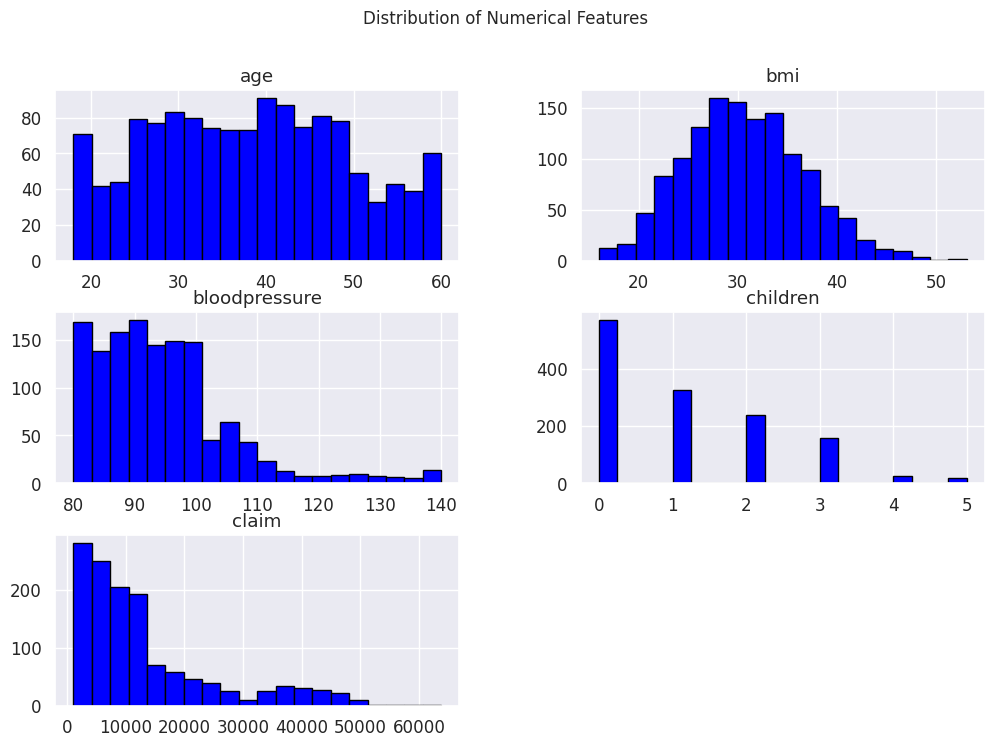

In [34]:
numeric_cols = ["age","bmi","bloodpressure","children","claim"]
df[numeric_cols].hist(bins=20, figsize=(12, 8),color="blue", edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=12)
plt.show()


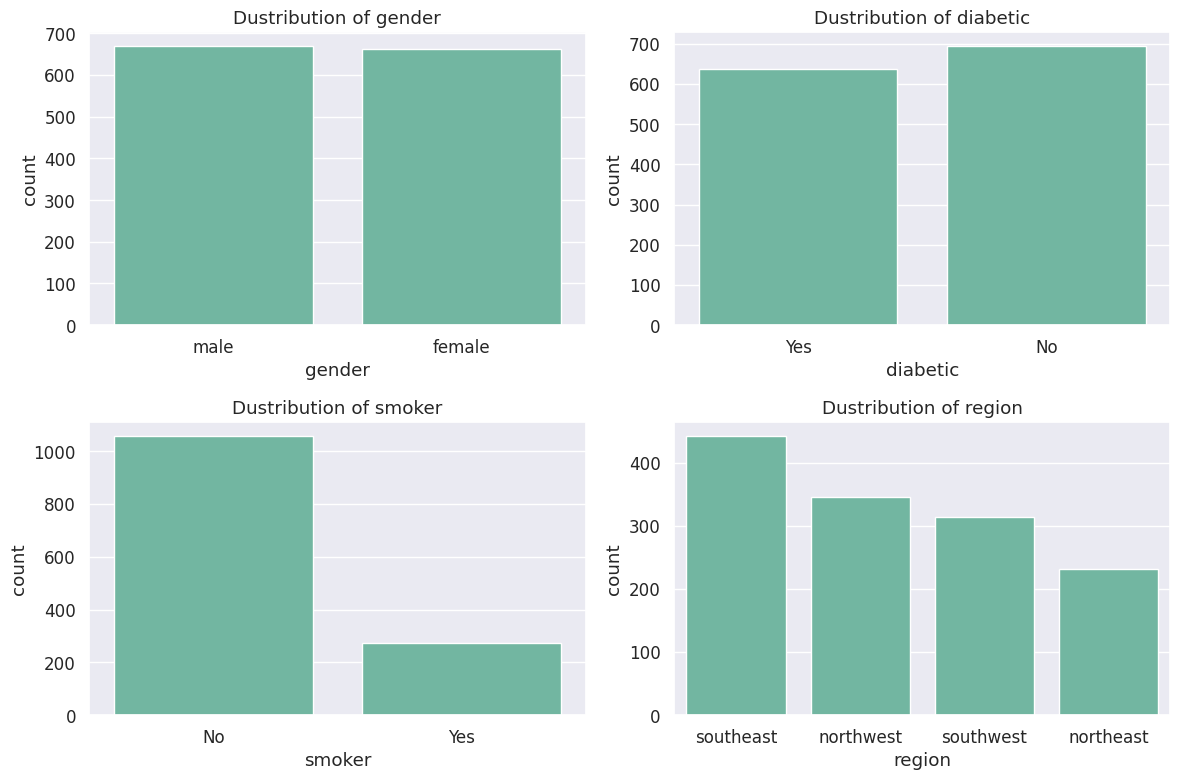

In [28]:
cat_cols = ["gender", "diabetic","smoker","region"]
plt.figure(figsize=(12, 8))
for i, col in enumerate(cat_cols,1):
  plt.subplot(2,2,i)
  sns.countplot(data=df, x=col)
  plt.title(f"Dustribution of {col}")
plt.tight_layout()

In [29]:
df.groupby(["gender","smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

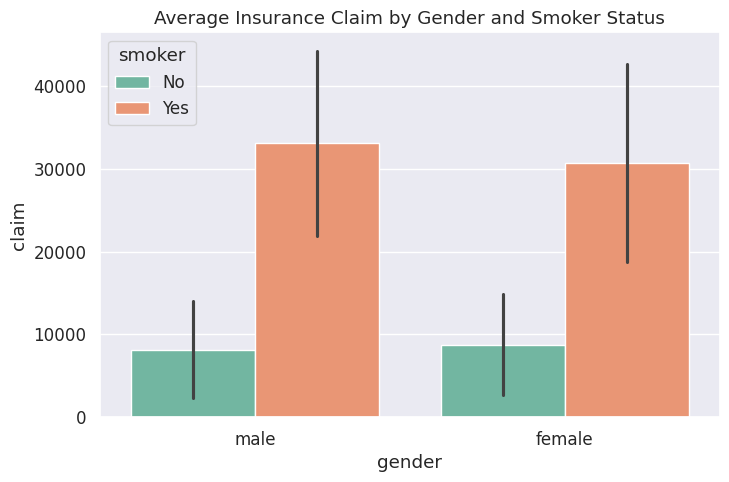

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="gender", y="claim", hue="smoker", estimator="mean",errorbar="sd")
plt.title("Average Insurance Claim by Gender and Smoker Status")
plt.show()

In [35]:
pivot_region_diabetic = df.groupby(["region", "diabetic"])["claim"].mean().unstack()
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


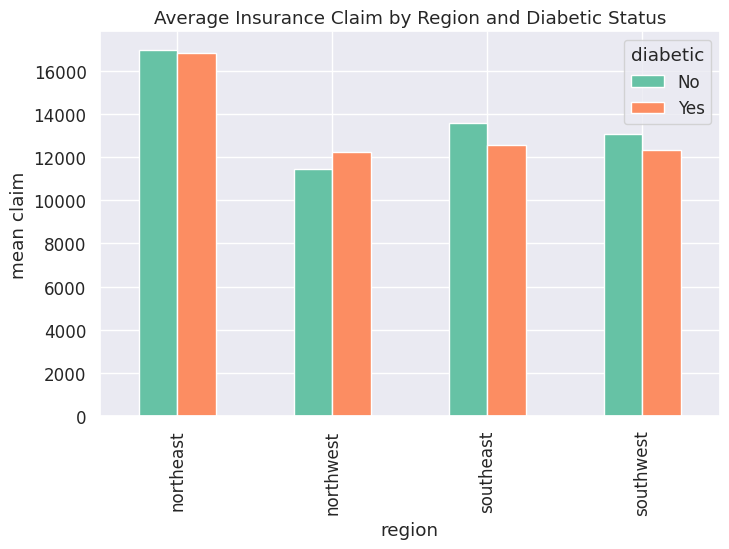

In [36]:
pivot_region_diabetic.plot(kind="bar", figsize=(8, 5))
plt.title("Average Insurance Claim by Region and Diabetic Status")
plt.ylabel("mean claim")
plt.show()

In [37]:
pivot_table = pd.pivot_table(df, index="region", columns="smoker", values="claim", aggfunc="mean")
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [38]:
pivot_table = pd.pivot_table(df, index="children", columns="diabetic", values="claim", aggfunc="mean")
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


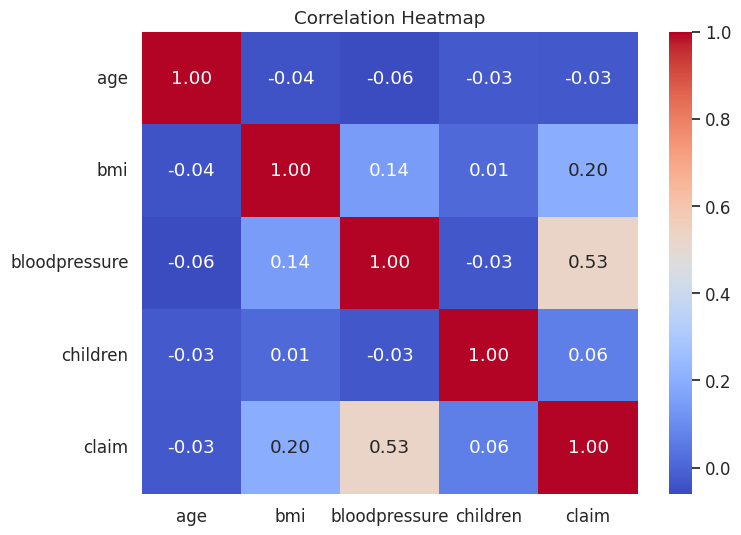

In [41]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

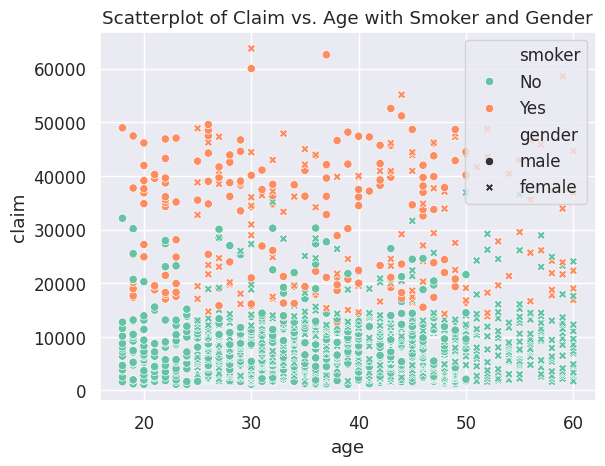

In [43]:
sns.scatterplot(data=df, x= "age", y= "claim", hue= "smoker", style= "gender")
plt.title(  "Scatterplot of Claim vs. Age with Smoker and Gender")
plt.show()

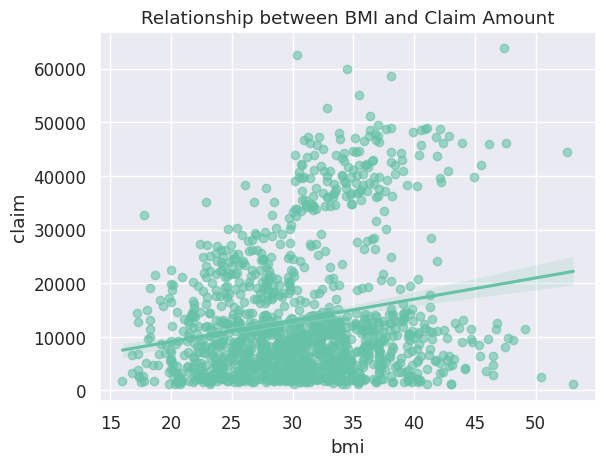

In [45]:
sns.regplot(data = df, x="bmi", y="claim", scatter_kws={"alpha":0.6})
plt.title("Relationship between BMI and Claim Amount")
plt.show()

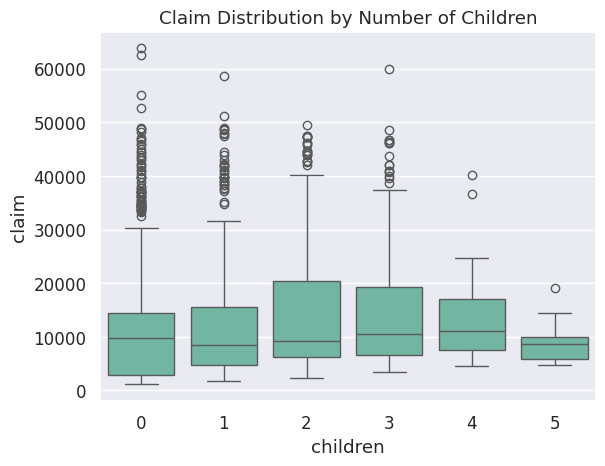

In [46]:
sns.boxplot(data=df,x="children", y="claim")
plt.title("Claim Distribution by Number of Children")
plt.show()

In [49]:
df["age_group"] = pd.cut(df["age"], bins=[0,18,30,45,60,100], labels=["<18", "18-30", "31-45", "46-60", "60+"])
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,31-45
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,18-30
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,31-45


In [50]:
df["age_group"].value_counts()

,count
age_group,
31-45,553
46-60,383
18-30,380
<18,16
60+,0


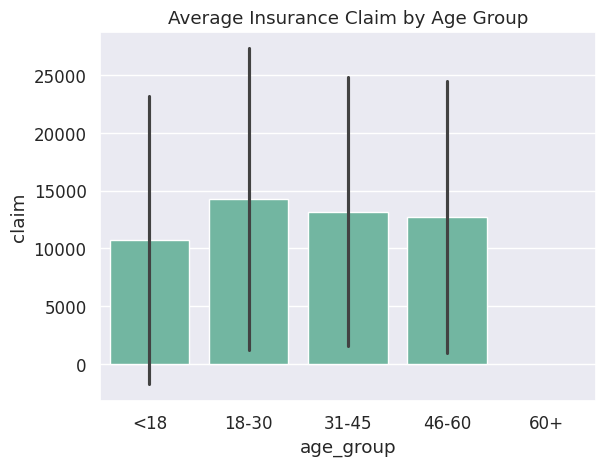

In [51]:
sns.barplot(data=df, x="age_group", y="claim", estimator="mean", errorbar="sd")
plt.title("Average Insurance Claim by Age Group")
plt.show()

In [52]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 18.5, 24.9, 29.9, 100], labels = ["Underweight", "Normal", "Overweight", "Obese"])
df["bmi_category"].value_counts()

,count
bmi_category,
Obese,702
Overweight,387
Normal,222
Underweight,21


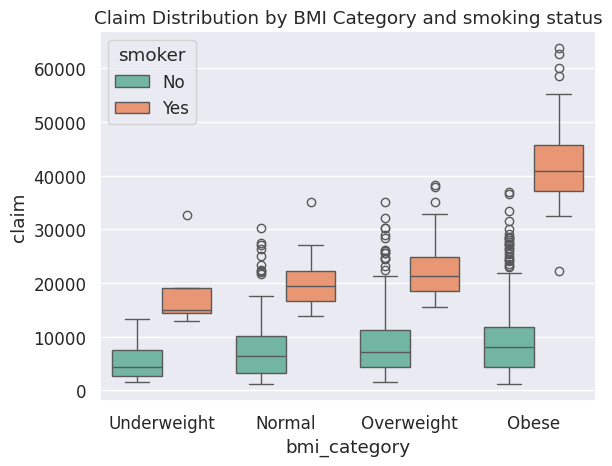

In [53]:
sns.boxplot(data=df, x="bmi_category", y="claim", hue ="smoker")
plt.title("Claim Distribution by BMI Category and smoking status")
plt.show()

In [55]:
region_stats = df.groupby("region").agg(
    smoker_rate = ("smoker", lambda x: (x=="Yes").mean() * 100),
    mean_claim = ("claim", "mean")
    ).reset_index()

In [56]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


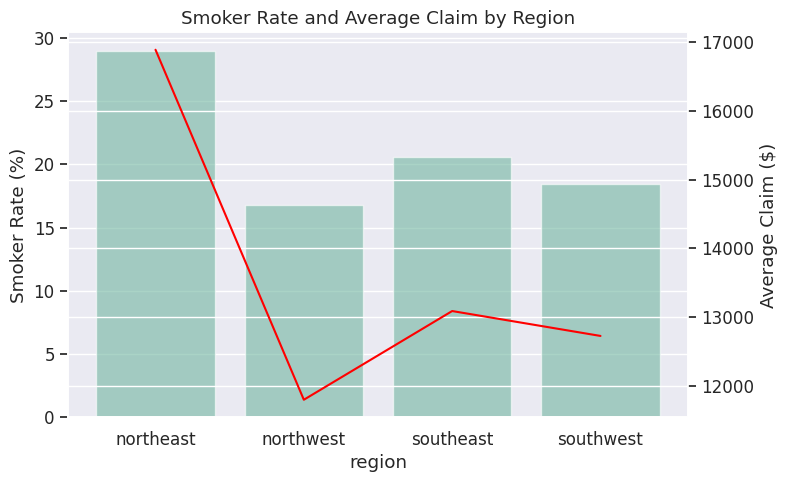

In [58]:
fig, ax1 = plt.subplots(figsize=(8,5))
sns.barplot(data = region_stats, x="region", y= "smoker_rate", ax=ax1, alpha=0.6)
ax2=ax1.twinx()
sns.lineplot(data=region_stats, x="region", y="mean_claim", color="red", ax=ax2)
ax1.set_ylabel("Smoker Rate (%)")
ax2.set_ylabel("Average Claim ($)")
plt.title("Smoker Rate and Average Claim by Region")
plt.show()

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [60]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [64]:
x= df[["age","gender", "bmi", "bloodpressure", "diabetic", "children", "smoker", "region"]]
y= df["claim"]

In [91]:
cat_cols = ["gender", "diabetic","smoker", "region"]
label_encoders = {}

In [92]:
x

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region
0,39.00,1,23.20,91,1,0,0,southeast
1,24.00,1,30.10,87,0,0,0,southeast
7,19.00,1,41.10,100,0,0,0,northwest
8,20.00,1,43.00,86,0,0,0,northwest
9,30.00,1,53.10,97,0,0,0,northwest
...,...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1,northwest
1336,59.00,0,38.10,120,0,1,1,northeast
1337,30.00,1,34.50,91,1,3,1,northwest
1338,37.00,1,30.40,106,0,0,1,southeast


In [112]:
for col in cat_cols:
  le = LabelEncoder()
  x.loc[:, col] = le.fit_transform(x[col])
  # Explicitly cast to category dtype after label encoding
  x.loc[:, col] = x.loc[:, col].astype('category')
  label_encoders[col] = le
  joblib.dump(le, f"label_encoder_{col}.pkl")

In [113]:
x

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region
0,39.00,1,23.20,91,1,0,0,2
1,24.00,1,30.10,87,0,0,0,2
7,19.00,1,41.10,100,0,0,0,1
8,20.00,1,43.00,86,0,0,0,1
9,30.00,1,53.10,97,0,0,0,1
...,...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1,1
1336,59.00,0,38.10,120,0,1,1,0
1337,30.00,1,34.50,91,1,3,1,1
1338,37.00,1,30.40,106,0,0,1,2


In [114]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder(),
 'region': LabelEncoder()}

In [115]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [116]:
num_cols = ["age","bmi","bloodpressure","children"]
scaler = StandardScaler()

In [117]:
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [118]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [119]:
print(x_train.shape, y_train.shape)

(1065, 8) (1065,)


In [120]:
print(x_test.shape, y_test.shape)

(267, 8) (267,)


In [121]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor


In [122]:
def evaluate_model(model, x_train, x_test, y_train, y_test):
  y_pred = model.predict(x_test)
  r2 = r2_score(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  return {"R2": r2, "MAE": mae, "RMSE": rmse}


In [123]:
results ={}

In [124]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

In [127]:
lr = LinearRegression()
lr.fit(x_train, y_train)
results["Linear Regression"] = evaluate_model(lr, x_train, x_test, y_train, y_test)
print("Linear Regression Model Trained")

best_poly_model = None
best_poly_score = -np.inf

for degree in [2,3]:
  poly = PolynomialFeatures(degree= degree)
  x_train_poly = poly.fit_transform(x_train)
  x_test_poly = poly.transform(x_test)

  poly_lr = LinearRegression()
  poly_lr.fit(x_train_poly, y_train)

  score = poly_lr.score(x_test_poly, y_test)

  if score > best_poly_score:
    best_poly_score = score
    best_poly_model = (degree, poly, poly_lr)

degree, poly, poly_lr = best_poly_model

results["Polynomial Regression"] = evaluate_model(poly_lr, poly.fit_transform(x_train), poly.transform(x_test), y_train, y_test)
print("Polynomial Regression Models are Trained")

rf = RandomForestRegressor()
rf_params = {
    "n_estimators": [100,200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2]}

rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring= "r2", n_jobs= -1, verbose = 0)
rf_grid.fit(x_train, y_train)
best_rf_model = rf_grid.best_estimator_
results["Random Forest"] = evaluate_model(best_rf_model, x_train, x_test, y_train, y_test)
print("Random Forest training is completed, best parameters:", rf_grid.best_params_)

svr = SVR()
svr_params = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [1, 10, 50],
    "epsilon": [0.1, 0.2, 0.5],
    "degree": [2, 3]}

svr_grid = GridSearchCV(svr, svr_params, cv=3, scoring= "r2", n_jobs= -1, verbose = 0)
svr_grid.fit(x_train, y_train)

best_svr_model = svr_grid.best_estimator_

results["SVR"] = evaluate_model(best_svr_model, x_train, x_test, y_train, y_test)
print("SVR training is completed, best parameters:", svr_grid.best_params_)

# Ensure categorical columns in x_train and x_test are explicitly of category dtype for XGBoost
# This step is added to address the persistent 'region: object' error in XGBoost
for col in cat_cols:
    if col in x_train.columns:
        x_train[col] = x_train[col].astype('category')
    if col in x_test.columns:
        x_test[col] = x_test[col].astype('category')

xgb = XGBRegressor(objective="reg:squarederror", enable_categorical=True)
xgb_params = {
    "n_estimators": [100,200],
    "learning_rate": [0.01, 0.05,0.1],
    "max_depth": [3,5,7],
    "subsample": [0.8, 1.0]
    }

xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring= "r2", n_jobs= -1, verbose = 0)
xgb_grid.fit(x_train, y_train)
best_xgb_model = xgb_grid.best_estimator_

results["XGBoost"] = evaluate_model(best_xgb_model, x_train, x_test, y_train, y_test)
print("XGBoost training is completed, best parameters:", xgb_grid.best_params_)

Linear Regression Model Trained
Polynomial Regression Models are Trained
Random Forest training is completed, best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
SVR training is completed, best parameters: {'C': 50, 'degree': 2, 'epsilon': 0.1, 'kernel': 'linear'}
XGBoost training is completed, best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [128]:
results

{'Linear Regression': {'R2': 0.7373371805917703,
  'MAE': 4737.700055082579,
  'RMSE': np.float64(6184.87742168621)},
 'Polynomial Regression': {'R2': 0.7918670653961111,
  'MAE': 4073.4637277086454,
  'RMSE': np.float64(5505.5688713075615)},
 'Random Forest': {'R2': 0.8229564203152816,
  'MAE': 3788.231763963531,
  'RMSE': np.float64(5077.756689548772)},
 'SVR': {'R2': 0.5547841150132198,
  'MAE': 5488.463607274833,
  'RMSE': np.float64(8052.247617387284)},
 'XGBoost': {'R2': 0.8370489551010263,
  'MAE': 3758.517535697565,
  'RMSE': np.float64(4871.473795626568)}}

In [129]:
results_df = pd.DataFrame(results).T.sort_values(by="R2", ascending=False)
results_df

,R2,MAE,RMSE
XGBoost,0.84,3758.52,4871.47
Random Forest,0.82,3788.23,5077.76
Polynomial Regression,0.79,4073.46,5505.57
Linear Regression,0.74,4737.70,6184.88
SVR,0.55,5488.46,8052.25


In [131]:
models ={
    "Linear Regression": lr,
    "Polynomial Regression": poly_lr,
    "Random Forest": best_rf_model,
    "SVR": best_svr_model,
    "XGBoost": best_xgb_model
}

In [132]:
best_r2 = results_df["R2"].max()
best_r2

0.8370489551010263

In [133]:
top_model = results_df[results_df["R2"] == best_r2]
top_model

,R2,MAE,RMSE
XGBoost,0.84,3758.52,4871.47


In [134]:
best_model = models[top_model.index[0]]
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [136]:
joblib.dump(best_model, "best_model.pkl")
print(f"Best model Selected: {top_model.index[0]}")

Best model Selected: XGBoost
